In [1]:
import os
import sys

paths = [
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/myopacus",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/torchdp",
    "/your/path/rpdp_fl/experiments",
]

for p in paths:
    if p not in sys.path:
        sys.path.append(p)

# Optional: also update environment variable
os.environ["PYTHONPATH"] = ":".join(sys.path)

In [6]:
from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "heart_disease"   # change to "fashion_mnist" when needed

all_results = []

data_types = [
    "niid_10_5",
    
]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_unidp_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))

Loading: ./fed_heart_disease/niid_10_5/ditto/niid_10_5_results_ditto_unidp_heart_disease.csv


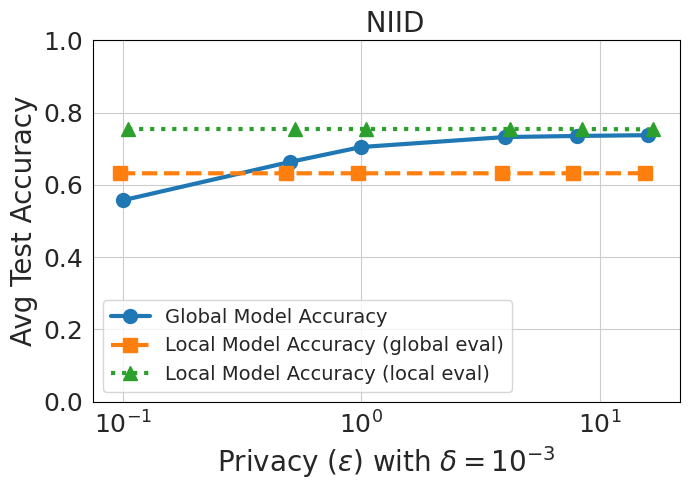

In [10]:
import numpy as np
import ast
import json
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor':'black'}) 

#datasets = ['MNIST IID', 'MNIST NIID-5', 'MNIST NIID-1', 'MNIST Dirch-5', 'MNIST Dirch-1']
dataset_names = [ 'IID' ,' Dirch-5', ' NIID', ' Dirch-1', ' NIID-2',]

methods = ['global', 'pooled', 'personal']  # must match CSV exactly

method_labels = {
    'global': 'Global Model Accuracy',
    'pooled': 'Local Model Accuracy (global eval)',
    'personal': 'Local Model Accuracy (local eval)'
}

offset_map = {
    'global': 1.0,
    'pooled': 0.97,     # slight left shift
    'personal': 1.05    # slight right shift
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',        # solid
    'pooled': '--',       # dashed
    'personal': ':'       # dotted
}

marker_map = {
    'global': 'o',   # circle
    'pooled': 's',   # square
    'personal': '^'  # triangle
}

NUM_STEPS = 15  # change if needed


# ========================
# Plot each dataset separately
# ========================
for d_idx, df in enumerate(all_results):

    # Ensure numeric epsilon
    df['e'] = df['e'].astype(float)

    # Filter by personal steps
    df = df[df['num_personal_steps'] == NUM_STEPS] # Filter by personal steps
    df = df[df['lambda'] == 0] # Filter by no personalization 


    # ========================
    # Average across seeds
    # ========================
    df_grouped = (
        df.groupby(['e', 'type'])['mean_perf']
        .mean()
        .reset_index()
    )

    # ========================
    # Plot
    # ========================
    plt.figure(figsize=(7, 5))

    for method in methods:
        df_m = df_grouped[df_grouped['type'] == method]

        if len(df_m) == 0:
            continue

        df_m = df_m.sort_values(by='e')

        x = df_m['e'].values * offset_map[method]
        
        plt.plot(
            x,
            df_m['mean_perf'],
            label=method_labels[method],
            linestyle=linestyle_map[method],
            marker= marker_map[method],
            color=colors[method],
            linewidth = 3,
            markersize = 10
        )

    plt.xscale('log')
    plt.xlabel(r"Privacy ($\epsilon$) with $\delta = 10^{-3}$", fontsize=20)
    plt.ylabel("Avg Test Accuracy", fontsize=20)
    plt.title(f" {dataset_names[2]}",fontsize=20)
    plt.tick_params(axis='both', labelsize=18)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend(fontsize=14)

    plt.tight_layout()
    plt.show()